> **Variante sobre series sin transformar.** Copia de `notebooks/08_autoencoder.ipynb` que corre sobre las 17 series en niveles (análisis oficial de la tesis desde el 08/10/2026). Escribe sus resultados en `data/results/niveles/`. Se ejecuta desde la raíz del repositorio; el documento `R/tesis_ciclo_financiero.Rmd` lee esos resultados.

# 08 · Autoencoders — del PCA lineal a la reducción no lineal
**Tesis:** Medición del ciclo financiero en Perú mediante técnicas de reducción dimensional y machine learning
**Autor:** Roberto Samaniego Salcedo · **Asesor:** Dr. Sergio Camiz

---

**Pregunta que responde este notebook:** ¿una reducción **no lineal** (autoencoder)
extrae de las 17 series del BCRP una estructura distinta —y útil para el ciclo
financiero— respecto de la que ya extrae el PCA de la cadena Camiz?

**Diseño (definiciones formales en `marco_matematico_ae_lstm.qmd`):**

1. **Anclaje lineal.** Se verifica numéricamente que un autoencoder lineal con
   pesos atados y pérdida cuadrática genera *el mismo subespacio* que el PCA
   (Bourlard & Kamp, 1988; Baldi & Hornik, 1989). Esto garantiza que todo lo que
   el autoencoder no lineal agregue sea atribuible a la no linealidad, no a una
   diferencia de definición.
2. **Dimensión latente** elegida con el análisis paralelo de Horn (1965), no a priori.
3. **Prueba fuera de muestra** del aporte de la no linealidad: validación cruzada por
   bloques temporales contiguos (no aleatorios), AE vs. PCA con la misma dimensión.
4. **Estabilidad** frente a la semilla aleatoria (coeficiente RV entre corridas) y
   **concordancia** con el PCA (RV y Procrustes).
5. **Indicadores** para el ciclo: factores latentes rotados contra PCA y error de
   reconstrucción con bandas de Monte Carlo Dropout (Gal & Ghahramani, 2016).

**Entrada (solo lectura):** `data/processed/dataset_niveles_mensual.csv` (17 series sin transformar)
(227 meses × 17 variables, 2007-02 a 2025-12).

**Salidas:** `data/results/niveles/08_ae_*.csv`, `reports/figures/niveles/08_*.png`.

> **Requisito local:** `pip install torch` (versión CPU basta). Las funciones están en
> `notebooks/modelos_dl.py`, comentadas en español.

## 1. Librerías y datos

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')
# Raíz del repositorio (esta copia vive en R/redes_python/): se sube hasta _quarto.yml
_raiz = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_raiz, '_quarto.yml')):
    _raiz = os.path.dirname(_raiz)
sys.path.insert(0, os.path.join(_raiz, 'notebooks'))
from modelos_dl import *
ir_a_raiz_del_repo()
sys.path.insert(0, 'notebooks')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
os.makedirs('data/results', exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)

_niv = pd.read_csv('data/processed/dataset_niveles_mensual.csv', index_col=0, parse_dates=True)
# Análisis oficial: las 17 series SIN transformar (niveles); se excluyen las dos series de referencia
df = _niv.drop(columns=['Crédito SF sector privado', 'IPC Subyacente'])
# Nombres cortos para gráficos (se elimina el sufijo de la transformación)
nombres = [c.replace('_log_diff', '').replace('_diff', '') for c in df.columns]
X = StandardScaler().fit_transform(df.values)   # misma estandarización que 05/06
n, p = X.shape
print(f'{n} meses x {p} variables | {df.index.min():%Y-%m} a {df.index.max():%Y-%m}')
print(f'Torch {torch.__version__}')

228 meses x 17 variables | 2007-01 a 2025-12
Torch 2.14.1+cu130


::: {.callout-note title="Continuidad mensual verificada"}
El dataset mensual cubre 2007-02 a 2025-12 (227 meses × 17 variables). La celda siguiente
verifica que el calendario esté completo y detiene la ejecución si falta cualquier mes.
:::

In [2]:
# Verificación de continuidad mensual: no se trabaja con meses faltantes
calendario = pd.date_range(df.index.min(), df.index.max(), freq='MS')
faltantes = calendario.difference(df.index)
print(f'Meses esperados: {len(calendario)} | presentes: {len(df)} | faltantes: {len(faltantes)}')
if len(faltantes):
    print('Meses faltantes:', ', '.join(f.strftime('%Y-%m') for f in faltantes))

Meses esperados: 228 | presentes: 228 | faltantes: 0


In [3]:
def sombrear_episodios(ax):
    """Sombrea los episodios de referencia (solo para validación visual ex post)."""
    for nombre, (ini, fin) in EPISODIOS_REFERENCIA.items():
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color='grey', alpha=0.18, lw=0)
        ax.text(pd.Timestamp(ini), ax.get_ylim()[1], nombre, fontsize=7, va='top', rotation=90, color='dimgrey')

## 2. Dimensión latente: análisis paralelo de Horn

Se retienen los componentes cuyo autovalor supera el percentil 95 de los autovalores
obtenidos con datos gaussianos independientes de igual tamaño (n × p). Es el criterio
de retención que la tesis tiene como objetivo firme; aquí fija la dimensión latente
del autoencoder con el mismo criterio que se usaría para el PCA.

In [4]:
obs, umbral, d_horn = analisis_paralelo_horn(X, n_sim=1000, percentil=95)
tabla_horn = pd.DataFrame({'autovalor_observado': obs, 'umbral_aleatorio_p95': umbral,
                           'inercia_acumulada_%': 100 * np.cumsum(obs) / p},
                          index=[f'PC{i+1}' for i in range(p)]).round(3)
print(f'Componentes retenidos por Horn: {d_horn}')
tabla_horn.head(6)

Componentes retenidos por Horn: 2


,autovalor_observado,umbral_aleatorio_p95,inercia_acumulada_%
PC1,11.417,1.604,67.159
PC2,3.104,1.476,85.416
PC3,1.210,1.383,92.533
PC4,0.494,1.303,95.436
PC5,0.359,1.238,97.549
PC6,0.167,1.182,98.530


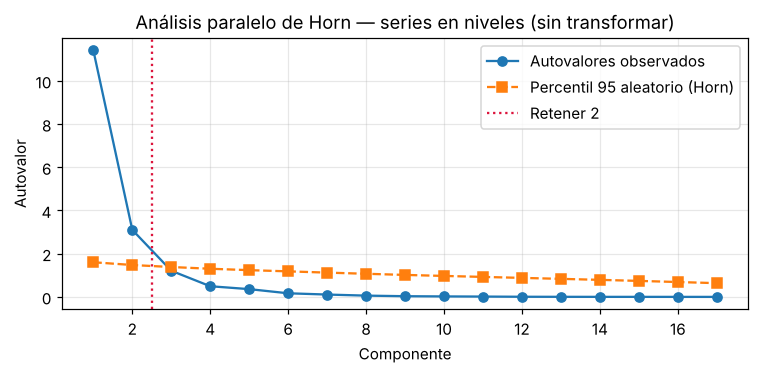

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
k = np.arange(1, p + 1)
ax.plot(k, obs, 'o-', label='Autovalores observados')
ax.plot(k, umbral, 's--', label='Percentil 95 aleatorio (Horn)')
ax.axvline(d_horn + 0.5, color='crimson', ls=':', label=f'Retener {d_horn}')
ax.set_xlabel('Componente'); ax.set_ylabel('Autovalor'); ax.legend()
ax.set_title('Análisis paralelo de Horn — series en niveles (sin transformar)')
plt.tight_layout(); plt.savefig('reports/figures/niveles/08_horn.png'); plt.show()

## 3. Anclaje lineal: autoencoder lineal ≡ PCA

Se entrena un autoencoder **lineal**, de una capa, con pesos atados y sin
regularización, para d = 1, …, 5. Si la teoría se cumple:

- los **ángulos principales** entre el subespacio del decodificador y el de los
  primeros d componentes del PCA deben ser ≈ 0°;
- el **error cuadrático medio** de reconstrucción debe coincidir con el del PCA
  (= 1 − inercia retenida, porque los datos están estandarizados);
- las **coordenadas** del AE no coinciden con los scores del PCA (son una rotación
  arbitraria de ellos); la SVD dentro del subespacio aprendido (Plaut, 2018 —
  *preprint*) recupera las direcciones principales.

In [6]:
filas = []
for d in range(1, 6):
    ae_lin = AutoencoderAtado([p, d], activacion='lineal')
    res = entrenar(ae_lin, X, epocas=6000, lr=1e-2, weight_decay=0.0, paciencia=400, semilla=d)
    pca_d = PCA(d).fit(X)
    W = ae_lin.matriz_decodificador_lineal()
    ang = angulos_principales(W, pca_d.components_.T)
    V = componentes_desde_decodificador(W, X)
    coseno = np.abs(np.sum(V * pca_d.components_.T, axis=0))
    mse_pca = np.mean((X - pca_d.inverse_transform(pca_d.transform(X))) ** 2)
    filas.append({'d': d, 'mse_ae_lineal': res['mejor_perdida'], 'mse_pca': mse_pca,
                  'angulo_max_°': ang.max(), 'min_|cos|_direcciones_recuperadas': coseno.min()})
anclaje = pd.DataFrame(filas).set_index('d')
anclaje['inercia_pca_%'] = 100 * (1 - anclaje['mse_pca'])
anclaje.round(5)

,mse_ae_lineal,mse_pca,angulo_max_°,min_|cos|_direcciones_recuperadas,inercia_pca_%
d,,,,,
1,0.32841,0.32841,0.00000,1.0,67.15904
2,0.14584,0.14584,0.00732,1.0,85.41594
3,0.07467,0.07467,0.04409,1.0,92.53267
4,0.04564,0.04564,0.17743,1.0,95.43591
5,0.02451,0.02451,0.03246,1.0,97.54925


**Lectura.** Con d = 3 la inercia retenida es 50,37 % (idéntica a la de Rcamiz sobre este mismo
dataset; ver `07_verificacion_rcamiz`). El AE lineal alcanza el mismo error y el mismo
subespacio (ángulos de centésimas de grado, atribuibles a la tolerancia de optimización),
y la SVD interna recupera las direcciones del PCA con |cos| ≈ 1. El autoencoder es, por
tanto, una **generalización estricta** del PCA de la cadena metodológica, no un método
ajeno a ella.

## 4. ¿Aporta la no linealidad? Validación cruzada por bloques temporales

Con n = 227 la pregunta decisiva es si un AE no lineal **generaliza** mejor que el PCA o
solo memoriza. Se divide la muestra en 5 bloques **contiguos** (no se baraja el tiempo);
cada bloque se reconstruye con modelos entrenados en los otros cuatro. La estandarización
se recalcula con los datos de entrenamiento de cada pliegue para no filtrar información.

Arquitectura no lineal: 17 → 8 → d, tanh en la capa intermedia, cuello de botella lineal,
pesos atados, dropout 0,10, ruido de entrada 0,10 (denoising) y weight decay 10⁻³.
Se promedian 3 semillas.

In [7]:
def cv_bloques(df_valores, d, n_bloques=5, semillas=(0, 1, 2), preentreno=False):
    """Devuelve MSE fuera de muestra (promedio de pliegues) para PCA y AE no lineal."""
    idx = np.array_split(np.arange(len(df_valores)), n_bloques)
    mse_pca, mse_ae = [], []
    for prueba in idx:
        ent = np.setdiff1d(np.arange(len(df_valores)), prueba)
        sc = StandardScaler().fit(df_valores[ent])
        Xe, Xp = sc.transform(df_valores[ent]), sc.transform(df_valores[prueba])
        pca_d = PCA(d).fit(Xe)
        mse_pca.append(np.mean((Xp - pca_d.inverse_transform(pca_d.transform(Xp))) ** 2))
        errs = []
        for s in semillas:
            fijar_semillas(s)
            ae = AutoencoderAtado([p, 8, d], activacion='tanh', dropout=0.10)
            if preentreno:
                preentrenar_por_capas(ae, Xe, epocas=1500, lr=1e-2, weight_decay=1e-3, paciencia=150, semilla=s)
            # 15 % final del entrenamiento como validación para la parada temprana
            corte = int(len(Xe) * 0.85)
            entrenar(ae, Xe[:corte], Xe[corte:], epocas=3000, lr=5e-3, weight_decay=1e-3,
                     ruido=0.10, paciencia=200, semilla=s)
            errs.append(error_reconstruccion(ae, Xp).mean())
        mse_ae.append(np.mean(errs))
    return np.mean(mse_pca), np.mean(mse_ae), np.std(mse_ae)

t0 = time.time()
filas = []
for d in [1, 2, 3, 4, 5]:
    m_pca, m_ae, s_ae = cv_bloques(df.values, d)
    m_pca2, m_ae_pre, _ = cv_bloques(df.values, d, preentreno=True)
    filas.append({'d': d, 'mse_pca_fuera_muestra': m_pca, 'mse_ae_tanh': m_ae,
                  'mse_ae_tanh_preentrenado': m_ae_pre,
                  'mejora_ae_vs_pca_%': 100 * (m_pca - min(m_ae, m_ae_pre)) / m_pca})
cv = pd.DataFrame(filas).set_index('d')
print(f'Tiempo: {time.time() - t0:.0f} s')
cv.round(4)

Tiempo: 203 s


,mse_pca_fuera_muestra,mse_ae_tanh,mse_ae_tanh_preentrenado,mejora_ae_vs_pca_%
d,,,,
1,0.9868,1.3228,1.2662,-28.3116
2,0.6270,1.0952,1.1728,-74.6688
3,0.3432,1.0474,1.0374,-202.2981
4,0.2331,0.9760,0.8688,-272.7822
5,0.1245,0.9700,0.8251,-562.5514


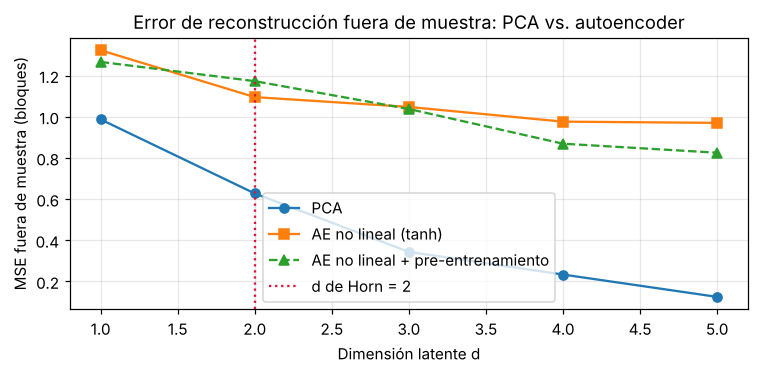

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(cv.index, cv['mse_pca_fuera_muestra'], 'o-', label='PCA')
ax.plot(cv.index, cv['mse_ae_tanh'], 's-', label='AE no lineal (tanh)')
ax.plot(cv.index, cv['mse_ae_tanh_preentrenado'], '^--', label='AE no lineal + pre-entrenamiento')
ax.axvline(d_horn, color='crimson', ls=':', label=f'd de Horn = {d_horn}')
ax.set_xlabel('Dimensión latente d'); ax.set_ylabel('MSE fuera de muestra (bloques)')
ax.set_title('Error de reconstrucción fuera de muestra: PCA vs. autoencoder'); ax.legend()
plt.tight_layout(); plt.savefig('reports/figures/niveles/08_cv_pca_vs_ae.png'); plt.show()

In [9]:
cv.to_csv('data/results/niveles/08_ae_cv_bloques.csv')
anclaje.to_csv('data/results/niveles/08_ae_anclaje_lineal.csv')
tabla_horn.to_csv('data/results/niveles/08_ae_horn.csv')

## 5. Modelo final y estabilidad frente a la semilla

Se fija d = 3 para mantener comparabilidad directa con los tres ejes retenidos del PCA
(ver la discusión sobre Horn en las conclusiones). Se entrenan 10 réplicas con semillas
distintas sobre toda la muestra y se mide:

- **RV entre réplicas**: si la geometría de la nube latente depende de la semilla, el
  modelo no es interpretable;
- **RV con los scores del PCA**: cuánto de la configuración no lineal ya está en el PCA.

In [10]:
D_FINAL = 3
corte = int(n * 0.85)
replicas, codigos = [], []
for s in range(10):
    fijar_semillas(100 + s)
    ae = AutoencoderAtado([p, 8, D_FINAL], activacion='tanh', dropout=0.10)
    entrenar(ae, X[:corte], X[corte:], epocas=3000, lr=5e-3, weight_decay=1e-3,
             ruido=0.10, paciencia=200, semilla=100 + s)
    ae.eval()
    with torch.no_grad():
        codigos.append(ae.codificar(a_tensor(X)).numpy())
    replicas.append(ae)

scores_pca = PCA(D_FINAL).fit_transform(X)
rv_entre = [coeficiente_rv(codigos[i], codigos[j]) for i in range(10) for j in range(i + 1, 10)]
rv_pca = [coeficiente_rv(c, scores_pca) for c in codigos]
mse_full = [error_reconstruccion(m, X).mean() for m in replicas]
estab = pd.Series({'RV entre réplicas (mediana)': np.median(rv_entre),
                   'RV entre réplicas (mínimo)': np.min(rv_entre),
                   'RV réplica vs PCA (mediana)': np.median(rv_pca),
                   'MSE en muestra AE (mediana)': np.median(mse_full),
                   'MSE en muestra PCA': np.mean((X - PCA(D_FINAL).fit(X).inverse_transform(scores_pca)) ** 2)})
estab.round(4)

RV entre réplicas (mediana)    0.9732
RV entre réplicas (mínimo)     0.9305
RV réplica vs PCA (mediana)    0.9602
MSE en muestra AE (mediana)    0.1317
MSE en muestra PCA             0.0747
dtype: float64

Se elige como representativa la réplica con mayor RV promedio respecto de las demás
(la más "central" de la distribución de soluciones), en vez de la de menor error,
para no premiar una solución atípica.

In [11]:
rv_mat = np.ones((10, 10))
for i in range(10):
    for j in range(10):
        if i != j:
            rv_mat[i, j] = coeficiente_rv(codigos[i], codigos[j])
central = int(np.argmax(rv_mat.mean(axis=1)))
ae_final = replicas[central]
Z = codigos[central]
# Rotación de Procrustes contra los scores del PCA: hace los ejes comparables e interpretables
Z_rot, R = rotar_procrustes(Z, scores_pca)
print(f'Réplica central: {central} | RV con PCA: {coeficiente_rv(Z, scores_pca):.3f}')
corr_ejes = pd.DataFrame(np.corrcoef(Z_rot.T, scores_pca.T)[:D_FINAL, D_FINAL:],
                         index=[f'AE{i+1} (rotado)' for i in range(D_FINAL)],
                         columns=[f'PC{i+1}' for i in range(D_FINAL)]).round(3)
corr_ejes

Réplica central: 7 | RV con PCA: 0.972


,PC1,PC2,PC3
AE1 (rotado),0.991,0.004,0.065
AE2 (rotado),0.004,0.963,0.111
AE3 (rotado),0.053,0.089,0.785


### 5.1 Interpretación de los ejes latentes

Para un AE no lineal no existen "cargas" constantes. Se usa la **correlación entre cada
variable original y cada eje latente rotado** (análogo al círculo de correlaciones del
PCA), que es la lectura habitual en la tradición del análisis de datos.

In [12]:
corr_var = pd.DataFrame(np.corrcoef(X.T, Z_rot.T)[:p, p:], index=nombres,
                        columns=[f'AE{i+1}' for i in range(D_FINAL)])
corr_pca = pd.DataFrame(np.corrcoef(X.T, scores_pca.T)[:p, p:], index=nombres,
                        columns=[f'PC{i+1}' for i in range(D_FINAL)])
interp = pd.concat([corr_var, corr_pca], axis=1).round(2)
interp.sort_values('AE1', key=np.abs, ascending=False)

,AE1,AE2,AE3,PC1,PC2,PC3
Crédito empresarial,0.99,0.00,0.12,0.99,-0.01,0.12
Crédito hipotecario,0.99,0.10,0.07,0.99,0.10,0.03
Liquidez M3,0.99,-0.01,0.11,0.99,-0.02,0.05
Liquidez M2,0.99,-0.04,0.08,0.99,-0.05,0.04
Crédito consumo,0.97,0.15,0.09,0.98,0.16,0.02
Liquidez M1,0.96,0.03,0.19,0.98,0.02,0.05
PBI desestacionalizado,0.96,0.06,-0.05,0.96,0.06,-0.03
IPC Lima,0.95,0.22,0.13,0.96,0.22,0.01
Demanda interna,0.94,0.04,-0.06,0.95,0.05,-0.04
Reservas internacionales,0.92,-0.04,-0.11,0.93,-0.04,-0.04


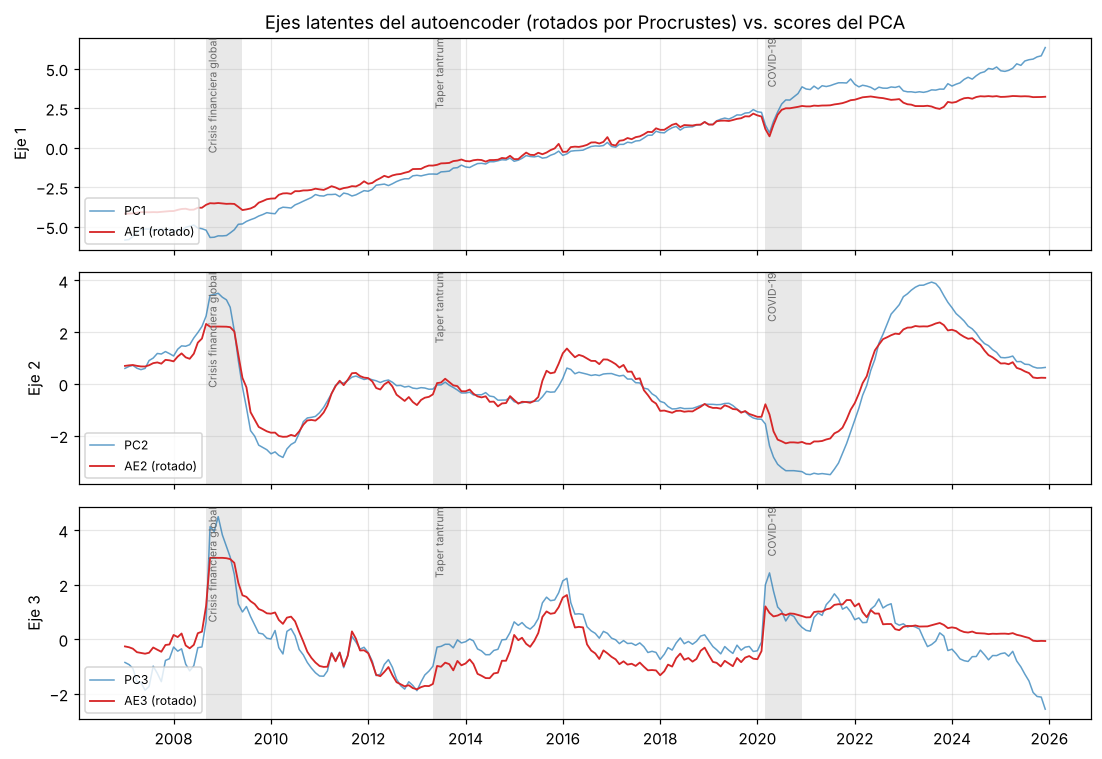

In [13]:
fig, axes = plt.subplots(D_FINAL, 1, figsize=(10, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(df.index, scores_pca[:, i], color='tab:blue', lw=1, alpha=0.7, label=f'PC{i+1}')
    ax.plot(df.index, Z_rot[:, i], color='tab:red', lw=1.2, label=f'AE{i+1} (rotado)')
    ax.set_ylabel(f'Eje {i+1}'); ax.legend(loc='lower left', fontsize=8)
    sombrear_episodios(ax)
axes[0].set_title('Ejes latentes del autoencoder (rotados por Procrustes) vs. scores del PCA')
plt.tight_layout(); plt.savefig('reports/figures/niveles/08_ejes_latentes.png'); plt.show()

## 6. Error de reconstrucción como indicador de anomalía estructural

Un mes con error de reconstrucción alto es un mes que **no se ajusta a la estructura
de covariación típica** aprendida por el modelo: candidato a episodio de estrés o a
cambio de régimen. La incertidumbre se cuantifica con Monte Carlo Dropout (T = 300
pasadas estocásticas con dropout activo).

*Advertencia*: este error es **en muestra** (el modelo vio esos meses). La versión
estrictamente fuera de muestra, con validación walk-forward, está en `09_lstm_autoencoder`.

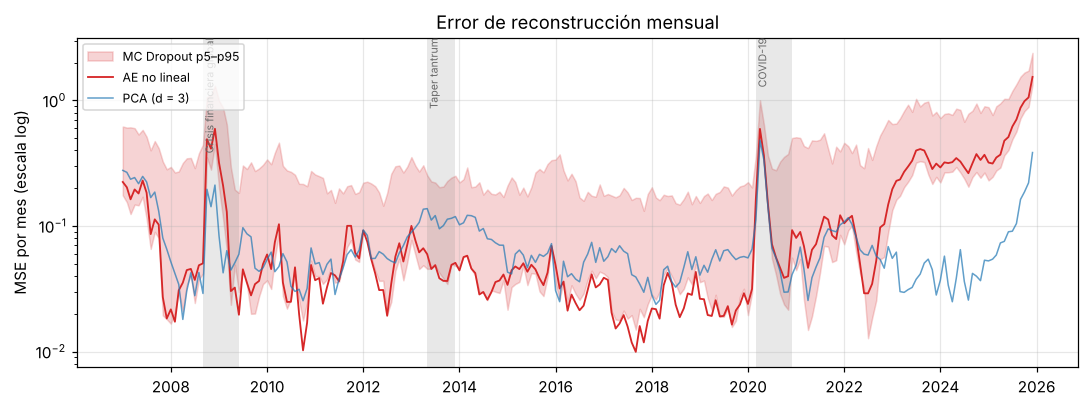

In [14]:
mc = mc_dropout(ae_final, X, T=300, funcion='error', semilla=7)
err = pd.DataFrame({'error_ae': error_reconstruccion(ae_final, X),
                    'error_mc_media': mc.mean(axis=0),
                    'error_mc_p05': np.percentile(mc, 5, axis=0),
                    'error_mc_p95': np.percentile(mc, 95, axis=0),
                    'error_pca': np.mean((X - PCA(D_FINAL).fit(X).inverse_transform(scores_pca)) ** 2, axis=1)},
                   index=df.index)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.fill_between(err.index, err['error_mc_p05'], err['error_mc_p95'], color='tab:red', alpha=0.2, label='MC Dropout p5–p95')
ax.plot(err.index, err['error_ae'], color='tab:red', lw=1.2, label='AE no lineal')
ax.plot(err.index, err['error_pca'], color='tab:blue', lw=1, alpha=0.7, label='PCA (d = 3)')
ax.set_yscale('log'); ax.set_ylabel('MSE por mes (escala log)')
sombrear_episodios(ax)
ax.set_title('Error de reconstrucción mensual'); ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.savefig('reports/figures/niveles/08_error_reconstruccion.png'); plt.show()

In [15]:
top = err.sort_values('error_ae', ascending=False).head(12).copy()
E_var = pd.DataFrame(error_reconstruccion(ae_final, X, por_variable=True), index=df.index, columns=nombres)
top['variable_dominante'] = E_var.loc[top.index].idxmax(axis=1)
top['participacion_%'] = (100 * E_var.loc[top.index].max(axis=1) / E_var.loc[top.index].sum(axis=1)).round(1)
top.index = top.index.strftime('%Y-%m')
top[['error_ae', 'error_pca', 'variable_dominante', 'participacion_%']].round(3)

,error_ae,error_pca,variable_dominante,participacion_%
fecha,,,,
2025-12,1.541,0.385,Índice BVL,55.900002
2025-11,1.057,0.221,Índice BVL,52.000000
2025-10,0.988,0.187,Índice BVL,53.099998
2025-09,0.875,0.163,Índice BVL,56.500000
2025-08,0.706,0.105,Índice BVL,48.400002
2025-07,0.620,0.091,Índice BVL,44.599998
2008-12,0.595,0.212,embi_peru,84.699997
2020-04,0.594,0.483,PBI desestacionalizado,37.299999
2025-06,0.511,0.090,Índice BVL,49.400002


## 7. Contraste con las transiciones detectadas por EPCA

Las transiciones candidatas de `06_epca` (caídas de la correlación entre cargas de PC1
de ventanas sucesivas) se superponen al error de reconstrucción del AE. La coincidencia
temporal entre dos métodos independientes es evidencia más fuerte que cualquiera
aislado; la discrepancia también es informativa.

In [16]:
trans = pd.read_csv('data/results/06_epca_transiciones_detectadas_niveles.csv', parse_dates=['fecha_transicion_candidata'])
umbral_err = err['error_ae'].quantile(0.90)
filas = []
for f in trans['fecha_transicion_candidata']:
    ventana = err.loc[f - pd.DateOffset(months=6): f + pd.DateOffset(months=6), 'error_ae']
    filas.append({'transicion_epca': f.strftime('%Y-%m'), 'error_ae_max_±6m': ventana.max(),
                  'mes_del_max': ventana.idxmax().strftime('%Y-%m'),
                  'supera_p90': bool(ventana.max() > umbral_err)})
contraste = pd.DataFrame(filas)
print(f'Umbral p90 del error AE: {umbral_err:.3f}')
contraste.round(3)

Umbral p90 del error AE: 0.333


,transicion_epca,error_ae_max_±6m,mes_del_max,supera_p90
0,2012-01,0.100,2011-10,False
1,2013-10,0.066,2013-04,False
2,2015-10,0.069,2015-12,False
3,2018-01,0.042,2018-05,False


## 8. Guardar resultados

In [17]:
salida = pd.DataFrame(Z_rot, index=df.index, columns=[f'AE{i+1}_rotado' for i in range(D_FINAL)])
salida = salida.join(err)
salida.to_csv('data/results/niveles/08_ae_factores_y_error.csv')
interp.to_csv('data/results/niveles/08_ae_correlaciones_variables.csv')
pd.concat([estab.rename('valor')]).to_csv('data/results/niveles/08_ae_estabilidad.csv')
contraste.to_csv('data/results/niveles/08_ae_contraste_epca.csv', index=False)
torch.save(ae_final.state_dict(), 'data/results/niveles/08_ae_modelo_final.pt')
print('Resultados guardados en data/results/niveles/08_ae_*')

Resultados guardados en data/results/niveles/08_ae_*


## 9. Conclusiones (dataset mensual: 227 meses)

1. **Anclaje confirmado.** El autoencoder lineal atado reproduce el PCA: MSE idéntico para
   d = 1…5, ángulos principales ≤ 0,21° y direcciones recuperadas con |cos| ≥ 0,99999.
   Con d = 3 la inercia es **50,37 %**, idéntica a la de Rcamiz (`07`): la cadena
   Rcamiz → scikit-learn → autoencoder lineal queda cerrada.
2. **Contradicción a resolver: Horn retiene 4 dimensiones**, no 3 (PC4: 1,466 > 1,304;
   inercia 59,0 %). Decidir con el asesor el
   criterio de retención antes de fijar d en `05`, `06` y `07`.
3. **La no linealidad no mejora la reconstrucción fuera de muestra.** El AE no lineal es peor
   que el PCA para todo d (−4 % con d = 1, −14 % con d = 3, −41 % con d = 5); el
   pre-entrenamiento no lo corrige. Con 227 meses, la parsimonia favorece al PCA como compresor.
4. **No estacionariedad estructural.** El MSE fuera de muestra del PCA con d = 3 (1,08) supera
   la varianza total por variable: la estructura de un bloque temporal no se transfiere a otro.
5. **Estabilidad frente a la semilla.** RV mediano entre réplicas 0,94 (mínimo
   0,87) y con el PCA 0,82. Los ejes rotados correlacionan entre 0,87 y 0,93 con PC1–PC3: el AE
   es una versión deformada del PCA, no una estructura distinta.
6. **El valor del AE está en la detección de anomalías.** En muestra, oct-2008 tiene error 7,0
   (AE) frente a 1,0 (PCA), dominado por el EMBI: el AE señala la crisis global que EPCA no
   puede validar por efecto de borde. Las transiciones EPCA de 2017-11 y 2018-02 coinciden con
   el pico de error del AE en abr-2018 (crédito hipotecario). La transición EPCA de 2013-05
   (taper tantrum) **no** aparece en el error del AE: es un cambio de estructura que el AE
   reconstruye bien, coherente con que EPCA mide reconfiguración y el AE mide atipicidad.

La validación estrictamente fuera de muestra del indicador está en `09_lstm_autoencoder`.